# The Capital Asset Pricing Model

> **Note**
>
> You are reading **Tidy Finance with Python**. You can find the
> equivalent chapter for the sibling **Tidy Finance with R**
> [here](../r/capital-asset-pricing-model.qmd).

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

from plotnine import *
from mizani.formatters import percent_format
from adjustText import adjust_text

The Capital Asset Pricing Model (CAPM) is one of the most influential
theories in finance and builds on the foundation laid by [Modern
Portfolio Theory](modern-portfolio-theory.qmd) (MPT). It was
simultaneously developed by @Sharpe1964, @Lintner1965, and @Mossin1966.
While MPT shows how to construct efficient portfolios, the CAPM extends
this framework to explain how assets should be priced in equilibrium
when all investors follow MPT principles. The CAPM is the simplest model
that aims to explain equilibrium asset prices and hence the cornerstone
for a myriad of extensions. In this chapter, we derive the CAPM,
illustrate the theoretical underpinnings and show how to estimate the
coefficients of the CAPM. For this final purpose, we download stock
market data, estimate betas using regression analysis, and evaluate
asset performance.

We use the following packages throughout this chapter:

## Asset Returns & Volatilities

Building on our analysis from the previous chapter on [Modern Portfolio
Theory](modern-portfolio-theory.qmd), we again examine the Dow Jones
Industrial Average constituents as an exemplary asset universe. We
download and prepare our monthly return data:



In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

url = ("https://www.ssga.com/us/en/institutional/etfs/library-content/"
       "products/fund-data/etfs/us/holdings-daily-us-en-dia.xlsx")

symbols = (pd.read_excel(url, skiprows=4, nrows=30)
  .get("Ticker")
  .tolist()
)

ssl._create_default_https_context = ssl.create_default_context

prices_daily = (yf.download(
    tickers=symbols, 
    start="2000-01-01", 
    end="2023-12-31", 
    progress=False,
    auto_adjust=False,
    multi_level_index=False
  ))

prices_daily = (prices_daily
  .stack()
  .reset_index(level=1, drop=False)
  .reset_index()
  .rename(columns={"Ticker": "symbol", "Date": "date", "Adj Close": "adjusted"})
)

prices_daily = (prices_daily
  .groupby("symbol")
  .apply(lambda x: x.assign(counts=x["adjusted"].dropna().count()))
  .reset_index(drop=True)
  .query("counts == counts.max()")
)

returns_monthly = (prices_daily
  .assign(
    date=prices_daily["date"].dt.to_period("M").dt.to_timestamp()
  )
  .groupby(["symbol", "date"], as_index=False)
  .agg(adjusted=("adjusted", "last"))
  .assign(
    ret=lambda x: x.groupby("symbol")["adjusted"].pct_change()
  )
)

/tmp/ipykernel_4849/4114876737.py:24: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
/tmp/ipykernel_4849/4114876737.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


The relationship between risk and return is central to the CAPM.
Intuitively, one may expect that assets with higher volatility should
also deliver higher expected returns. Instead, the CAPM’s key insight
states that not all risks are rewarded in equilibrium. Only so-called
systematic risk of an asset will determine the assets expected return.
To understand this, we need to distinguish between systematic and
idiosyncratic risk.

Company-specific events might affect individual stock prices, e.g., CEO
resignations, product launches, and earnings reports. These
idiosyncratic events don’t necessarily impact the overall market and
this asset-specific risk can be eliminated through diversification.
Therefore, we call this risk idiosyncratic. Systematic risk, on the
other hand, affects all assets in the market at the same time and
investors really dislike it because it cannot be diversified away.

## Portfolio Return & Variance

While we covered efficient portfolio choice in detail in the previous
chapter, CAPM relies on the introduction of a crucial new element: a
risk-free asset. This additional asset fundamentally changes the
investment opportunity set and leads to powerful conclusions about
efficient portfolio choice.

To recap, we considered a portfolio weight vector
$\omega\in\mathbb{R}^N$ which denotes investments into the available $N$
risky assets. So far we assumed $\sum_i^N \omega_i=1$, indicating that
all available wealth is invested across the asset universe without any
outside option. Now, we relax this assumption and instead assume that
all the remaining wealth, $1-\iota'\omega$, is invested in a risk-free
asset which pays a constant interest $r_f$. The expected portfolio
return for the portfolio of risky assets $\omega$ is then

$$\mu_\omega = \omega^{\prime}\mu + (1-\iota^{\prime}\omega)r_f = r_f + \omega^{\prime}\underbrace{(\mu-r_f)}_{\tilde\mu}.$$

where $\mu$ is the the vector of expected return of assets and $r_f$ is
the risk-free rate. In what follows, we refer to $\tilde\mu$ as the
vector of expected *excess* returns.

By assumption, the risk-free asset has zero volatility. Therefore, the
volatility of the portfolio is given by

$$\sigma_\omega = \sqrt{\omega^{\prime}\Sigma\omega}$$

where $\Sigma$ is the variance-covariance matrix of the returns.
Restating the optimal decision problem of an investor who wants to earn
a desired level of expected portfolio (excess) returns ($\bar\mu-r_f$)
with the lowest possible variance leads to the optimization problem

$$\min_\omega Z(\omega) = \min_\omega \omega^{\prime}\Sigma\omega - \lambda \left(\omega^{\prime}\tilde\mu-\bar\mu\right).$$

The first-order conditions for this optimization problem yield:

$$\frac{\partial Z}{\partial \omega} = 2\Sigma\omega - \lambda \tilde\mu = 0 \\\Leftrightarrow \omega^* = \frac{\lambda}{2}\Sigma^{-1}\tilde\mu$$

The constraint $\omega^{\prime}\tilde\mu_\omega\geq \bar\mu$ delivers

$$\bar\mu = \tilde\mu^{\prime}\omega^* = \frac{\lambda}{2}\tilde\mu^{\prime}\Sigma^{-1}\tilde\mu \\
\Rightarrow \lambda = \frac{2\bar\mu}{\tilde\mu^{\prime}\Sigma^{-1}\tilde\mu}.$$
Thus, the optimal portfolio weights are given by
$$\omega^* = \frac{\bar\mu}{\tilde\mu^{\prime}\Sigma^{-1}\tilde\mu}\Sigma^{-1}\tilde\mu.$$

Note that $\omega^*$ does not necessarily sum up to one as,
mechanically, the remainder $1-\iota^{\prime}\omega^*$ is invested in
the risk-free asset. However, scaling $\omega^*$ delivers the portfolio
of risky assets $\omega_\text{tan}$ such that

$$\omega_\text{tan} := \frac{\omega^*}{\iota'\omega^*}= \frac{\Sigma^{-1}(\mu-r_f)}{\iota^{\prime}\Sigma^{-1}(\mu-r_f)}.$$

Importantly, $\omega_\text{tan}$ is independent from $\bar\mu$! Thus,
irrespective of the desired level of expected returns (or the investors’
risk aversion), everybody chooses the same portfolio of risky assets.
The only variation arises from the amount of wealth invested into the
risk-free asset. Some investors may even choose to lever their risky
position by borrowing at the risk-free rate and investing more than
their actual wealth into the portfolio $\omega_\text{tan}$.

The portfolio

$$\omega_{tan}=\frac{\Sigma^{-1}\tilde\mu}{\iota^{\prime}\Sigma^{-1}\tilde\mu}$$

is central to the CAPM and is typically called the efficient tangency
portfolio.

For illustrative purposes, we compute the efficient tangency portfolio
for our hypothetical asset universe. As a realistic proxy for the
risk-free rate, we use the average13-week T-bill rate (traded with the
symbol ^IRX). Since the prices are quoted in annualized percentage
yields, we have to divide them by 100 and convert them to monthly rates.

In [3]:
risk_free_monthly = (
  yf.download("^IRX", start="2019-10-01", end="2024-09-30", progress=False,
    auto_adjust=False,
    multi_level_index=False)
  .reset_index()
  .rename(columns={"Date": "date", "Adj Close": "adjusted"})
  .assign(
    risk_free=lambda x: (1 + x["adjusted"] / 100)**(1/12) - 1
  )
  .dropna()
)

rf = risk_free_monthly["risk_free"].mean()

Next, we define the core parameters governing the distribution of asset
returns, $\Sigma$ and $\tilde\mu$.

In [4]:
assets = (returns_monthly
  .groupby("symbol", as_index=False)
  .agg(
    mu=("ret", "mean"),
    sigma=("ret", "std")
  )
)

sigma = (returns_monthly
  .pivot(index="date", columns="symbol", values="ret")
  .cov()
)

mu = (returns_monthly
  .groupby("symbol")["ret"]
  .mean()
  .values
)

We are ready to illustrate the resulting efficient frontier. Every
investor chooses to allocate a fraction of her wealth in the efficient
tangency portfolio $\omega_\text{tan}$ and the remainder in the
risk-free asset. The optimal allocation depends on the investor’s risk
aversion. As the risk-free asset, by definition, has a zero volatility,
the efficient frontier is a straight line connecting the risk-free asset
with the tangency portfolio. The slope of the line connecting the
risk-free asset and the tangency portfolio is

$$\frac{\omega^{\prime}_\text{tan}\mu-r_f}{\omega_\text{tan}^{\prime}\Sigma\omega_\text{tan}^{\prime}}.$$

Typically, the excess return of an asset scaled by its volatility,
$\frac{\tilde\mu_i}{\sigma_i}$, is called the Sharpe ratio of the asset.
Thus, the slope of the efficient frontier corresponds to the Sharpe
ratio of the tangency portfolio returns. By construction, the tangency
portfolio is the maximum Sharpe ratio portfolio.[1]

<a href="#fig-300" class="quarto-xref">Figure 1</a> shows the resulting
efficient frontiert with the efficient portfolio and a risk-free asset.

[1] We proof in the Appendix [Proofs](proofs.qmd) that the efficient
tangency portfolio $\omega_\text{tan}$ can also be derived as a solution
to the optimization problem
$\max_{\omega} \frac{\omega^{\prime}\tilde\mu}{\sqrt{\omega^{\prime}\Sigma\omega}} \text{ s.t. } \omega^{\prime}\iota=1.$

In [5]:
w_tan = np.linalg.solve(sigma, mu - rf)
w_tan = w_tan / np.sum(w_tan)

mu_w = w_tan.T @ mu
sigma_w = np.sqrt(w_tan.T @ sigma @ w_tan)

efficient_portfolios = pd.DataFrame([
  {"symbol": "\omega_{tan}", "mu": mu_w, "sigma": sigma_w},
  {"symbol": "r_f", "mu": rf, "sigma": 0}
])

sharpe_ratio = (mu_w - rf) / sigma_w

<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_4849/3712183774.py:8: SyntaxWarning: invalid escape sequence '\o'


@fig-300 shows the resulting efficient frontiert with the efficient portfolio and a risk-free asset. 

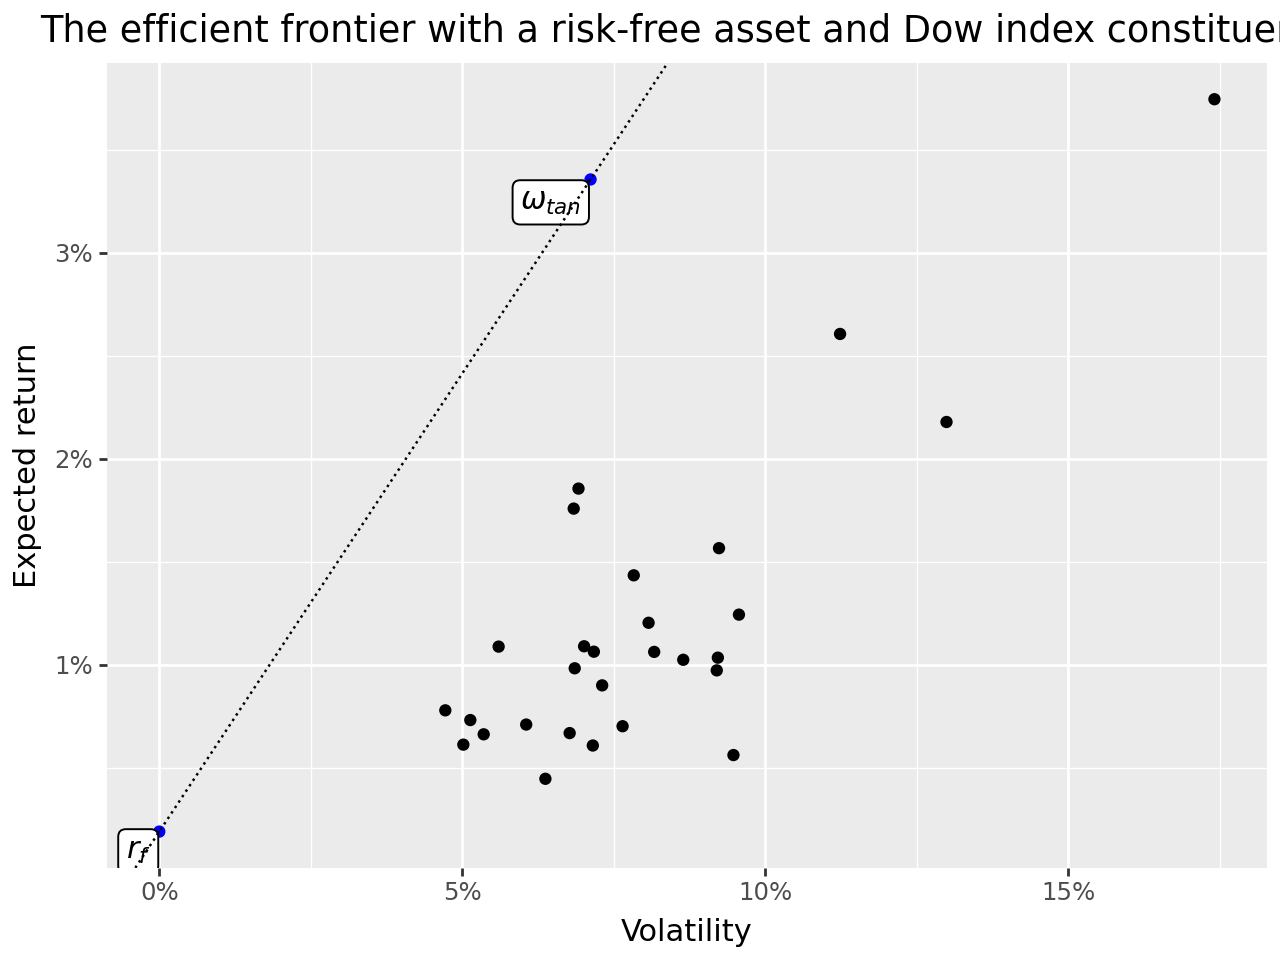

In [6]:
#| label: fig-300
#| fig-cap: "Expected returns and volatilities based on monthly returns adjusted for dividend payments and stock splits." 
#| fig-alt: "Title: The efficient frontier with a risk-free asset and Dow index constituents. The figure shows a scatter plot with volatities on the horizontal axis and expected returns on the vertical axis."
(
  ggplot(efficient_portfolios, aes(x="sigma", y="mu"))
  + geom_point(data=assets)
  + geom_point(data=efficient_portfolios, color="blue")
  + geom_label(
      aes(label="symbol"), parse=True, 
      adjust_text={"arrowprops": {"arrowstyle": "-"}}
    )
  + scale_x_continuous(labels=percent_format())
  + scale_y_continuous(labels=percent_format())
  + labs(
      x="Volatility", y="Expected return",
      title="The efficient frontier with a risk-free asset and Dow index constituents"
    )
  + geom_abline(aes(intercept=rf, slope=sharpe_ratio), linetype="dotted")
)

## The Capital Market Line

Taking another look at the efficient tangency portfolio
$\omega_\text{tan}$ reveals that expected asset excess returns
$\tilde\mu$ cannot be arbitrarily large or small. From the first order
condition of the optimization problem above we get, via simple
rearranging,

$$\frac{\partial Z}{\partial \omega} = 2\Sigma\omega - \lambda \tilde\mu =0 \\\Leftrightarrow \tilde\mu = \frac{2}{\lambda}\Sigma\omega^* = \frac{2}{\lambda}\underbrace{\iota'\omega^*}_{=\frac{\lambda}{2}\iota^{\prime}\Sigma^{-1}\tilde\mu}\Sigma\omega_\text{tan} \\ = \iota^{\prime}\Sigma^{-1}\tilde\mu\Sigma\omega_\text{tan}$$

Now, note the following three simple derivations:

1.  The expected excess return of the efficient tangency portfolio,
    $\tilde\mu_\text{tan}$ is given by
    $E(\omega_\text{tan}^{\prime} r - r_f) = \omega_\text{tan} \tilde\mu = \frac{\tilde\mu^{\prime}\Sigma^{-1}\tilde\mu}{\iota^{\prime}\Sigma^{-1}\tilde\mu}$.
2.  The variance of the returns of the efficient tangency portfolio
    $\sigma_\text{tan}^2$ is given by
    $\text{Var}(\omega_\text{tan}^{\prime} r) = \omega_\text{tan}^{\prime} \Sigma \omega_\text{tan}^{\prime} = \frac{\tilde\mu^{\prime}\Sigma^{-1}\tilde\mu}{(\iota^{\prime}\Sigma^{-1}\tilde\mu)^2}$.
    It follows that
    $\frac{\tilde\mu_\text{tan}}{\sigma_\text{tan}^2} = \iota^{\prime}\Sigma^{-1}\tilde\mu$
3.  The $i$-th element of the vector $\Sigma\omega_\text{tan}$ is
    $\sum\limits_{j=1}^N \sigma_{ij}\omega_{j,\text{tan}}= \text{Cov}\left(r_i, \sum\limits_{j=1}^N r_i'\omega_{j,\text{tan}}\right) = \text{Cov}\left(r_i, r_\text{tan}\right)$,
    which is the covariance of assets $i$ returns with the returns of
    the efficient tangency portfolio.

Putting everything together yields for the expected excess return of
asset $i$:

$$\tilde{\mu}_i = \frac{E(\omega_\text{tan}^{\prime}r - r_f)}{\sigma_{\text{tan}}^2} \text{Cov}\left(r_i,r_\text{tan}\right) = \beta_i \tilde{\mu}_\text{tan}.$$

The equation above is the famous CAPM equation and central to asset
pricing. It states that an assets expected excess return is proportional
to the assets return covariance with the efficient portfolio excess
returns. The price of risk is the excess return of the efficient
tangency portfolio. An asset with 0 beta has the same expected return as
the risk-free rate. An asset with a beta of 1 has the same expected
return as the efficient tangency portfolio. An asset with a negative
beta has expected returns lower than the risk-free asset - the very
definition of an insurance. Therefore, the CAPM equation explains why
some assets may have the same volatility but different returns: Because
their systematic risk ($\beta_i$) is different.

We derived the CAPM equation as a consequence of efficient wealth
allocation. Suppose an asset delivers high expected returns. The
investor will increase her holdings of the assets in order to benefit
from the high promised returns. As a consequence, the covariance of the
asset with the efficient tangency portfolio will increase (mechanically,
as the asset gradually becomes a larger part of the efficient tangency
portfolio). At some point, the weight of the asset is so high that gain
of $\tilde\mu_i$ of marginally increasing the holding does not offset
the implied increase in systematic risk. The investor will stop
increasing her holdings and the asset’s expected return will be
proportional to its systematic risk.

We can illustrate the relationship between systematic risk and expected
returns in the so-called security market line.

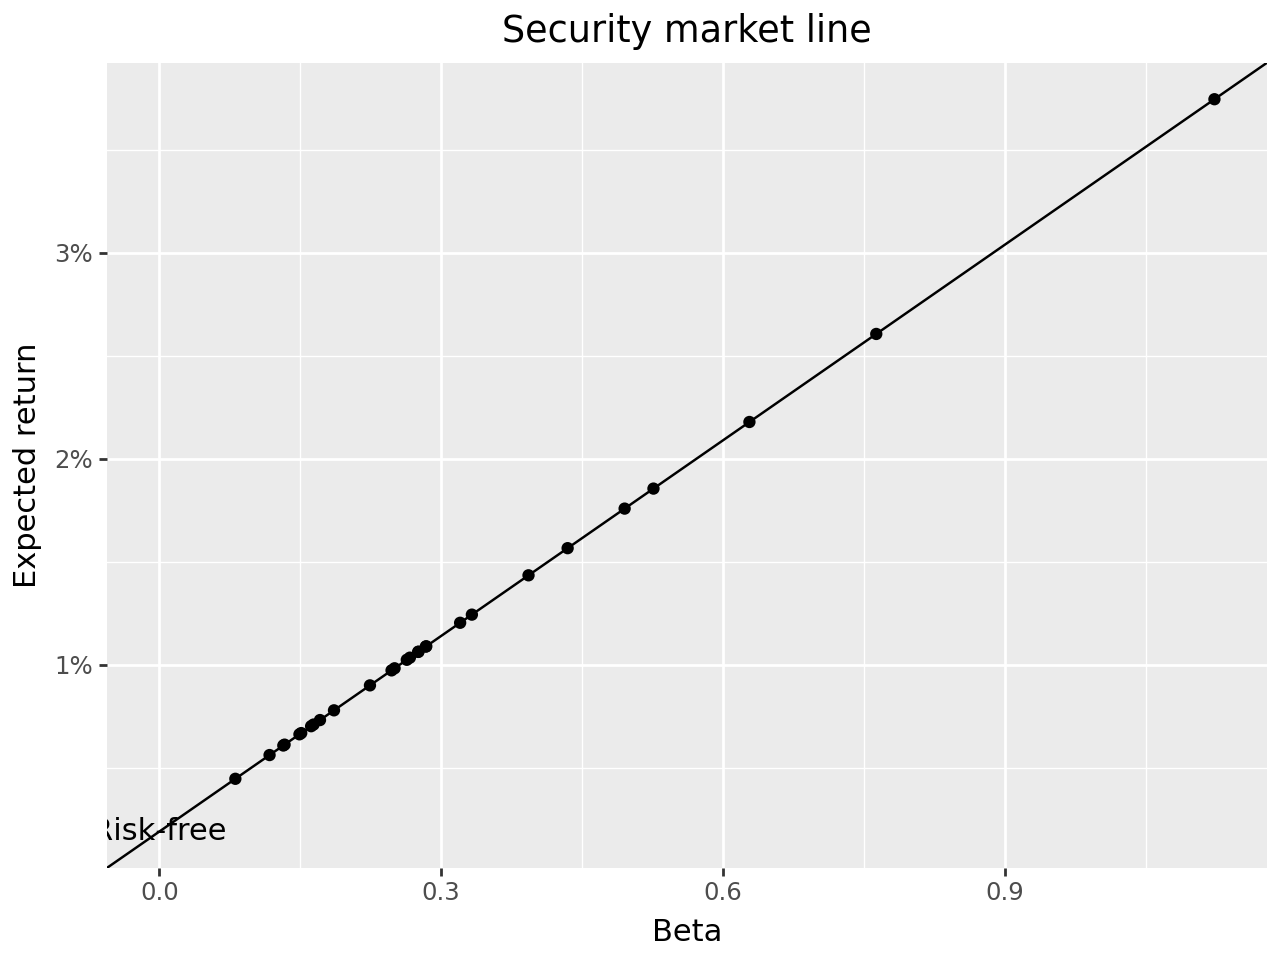

In [7]:
betas = (sigma @ w_tan) / (w_tan.T @ sigma @ w_tan)
assets["beta"] = betas.values

price_of_risk = float(w_tan.T @ mu - rf)

(
  ggplot(assets, aes(x="beta", y="mu"))
  + geom_point()
  + geom_abline(intercept=rf, slope=price_of_risk)
  + scale_y_continuous(labels=percent_format())
  + labs(
      x="Beta", y="Expected return",
      title="Security market line"
    ) 
  + annotate("text", x=0, y=rf, label="Risk-free")
)

The security market line shows the relationship between systematic risk
($\beta_i$) and the expected return of an asset. The slope of the line
is the price of risk, which is the expected return of the efficient
tangency portfolio. The risk-free asset is represented by the intercept
with the vertical axis. The CAPM equation states that an asset’s
expected return is proportional to its beta, with the efficient tangency
portfolio’s expected return as the price of risk.

## Asset Pricing and the Market Portfolio

So far, we focused on the optimal decision problem of an individual
investor. The capital asset pricing model goes an important step further
and considers the equilibrium in which all investors in the market
choose to hold efficient portfolios.

Based on the previous derivations, it should be clear that

1.  All rational investors prefer efficient portfolios to individual
    assets or any other portfolios.
2.  The tangency portfolio $\omega_\text{tan}$ serves as the optimal
    risky portfolio for all investors.

This leads to a powerful conclusion: In equilibrium, all investors hold
some combination of the risk-free asset and the tangency portfolio,
regardless of their risk preferences. Their only choice is how much to
allocate to each of the two funds. Aggregating all capital allocated to
risky assets yields the total market capitalization of all risky assets.
Given that everybody holds the same portfolio of risky assets, the
market capitalization of each asset is proportional to its weight in the
efficient tangency portfolio. The market portfolio is the sum of all
risky assets weighted by their market capitalization. For practical
purposes the insight that the market portfolio is the efficient tangency
portfolio, has substantial value: Instead of having to derive the vector
of expected asset returns and the variance-covariance matrix, we can use
the market portfolio as a proxy for the efficient tangency portfolio.
Market capitalization is readily observable and the market portfolio is
easy to replicate.[1]

Empirically, the CAPM-equation boils down to a linear regression:

$$r_{t,i}-r_f =  \beta_i (r_{m,t} - r_f) + \varepsilon_{i,t}.$$

Thus, a naive, but straightforward way of ‘estimating’ the CAPM is to
run a linear regression of asset excess returns on market excess
returns. The slope of the regression line is then the asset’s beta.

The potential intercept is the asset’s alpha, which measures the asset’s
risk-adjusted performance. If the CAPM holds, the alpha should be
statistically indistinguishable from zero for all assets. Alpha provides
a risk-adjusted performance measure. A positive alpha indicates that the
asset outperformed its risk-adjusted benchmark, while a negative alpha
suggests underperformance.

In practice, we hence estimate both alpha and beta using regression
analysis. The empirical model is:

$$r_{i,t}  - r_{f,t}  = \alpha_i + \beta_i \cdot (r_{m,t} - r_{f,t} ) + \varepsilon_{i,t}, $$
where $r_{i,t}$ and $r_{m,t}$ are the realized returns of the asset and
market portfolio on day $t$, respectively. The error term
$\varepsilon_{i,t}$ captures the asset’s idiosyncratic risk.

Let’s turn to estimating CAPM parameters using real market data. Instead
of using our previously constructed tangency portfolio, we employ the
Fama-French market excess returns, which provide a widely accepted proxy
for the market portfolio. These returns are already adjusted to
represent excess returns over the risk-free rate, simplifying our
analysis.



In [8]:
import pandas_datareader as pdr

factors_raw = pdr.DataReader(
  name="F-F_Research_Data_5_Factors_2x3",
  data_source="famafrench", 
  start="2000-01-01", 
  end="2024-09-30")[0]

factors = (factors_raw
  .divide(100)
  .reset_index(names="date")
  .assign(date=lambda x: pd.to_datetime(x["date"].astype(str)))
  .rename(str.lower, axis="columns")
  .rename(columns={"mkt-rf": "mkt_excess"})
)

/tmp/ipykernel_4849/3075237806.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
/tmp/ipykernel_4849/3075237806.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.


For our regression analysis, we first prepare the data by calculating
excess returns for each stock. We join our monthly returns with the
Fama-French factors and subtract the risk-free rate to obtain excess
returns. The `estimate_capm()` function then implements the regression
equation we previously discussed. We leverage nested dataframes to
efficiently run these regressions for all assets simultaneously. The
`map()` function applies our regression to each nested dataset and
extracts the coefficients, giving us a clean data frame of assets and
their corresponding betas.



In [9]:
import statsmodels.formula.api as smf

returns_excess_monthly = (returns_monthly
  .merge(factors, on="date", how="left")
  .assign(ret_excess=lambda x: x["ret"] - x["rf"])
)

def estimate_capm(data):
  model = smf.ols("ret_excess ~ mkt_excess", data=data).fit()
  result = pd.DataFrame({
    "coefficient": ["alpha", "beta"],
    "estimate": model.params.values,
    "t_statistic": model.tvalues.values
  })
  return result

capm_results = (returns_excess_monthly
  .groupby("symbol", group_keys=True)
  .apply(estimate_capm)
  .reset_index()
)

/tmp/ipykernel_4849/3903983297.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


The results are particularly interesting when we visualize the alphas
across our sample of Dow Jones constituents.
<a href="#fig-305" class="quarto-xref">Figure 2</a> reveals the
cross-sectional distribution of risk-adjusted performance, with positive
values indicating outperformance and negative values indicating
underperformance relative to what CAPM would predict. Statistical
significance is indicated through color coding, showing which alphas are
statistically different from zero at the 95% confidence level.

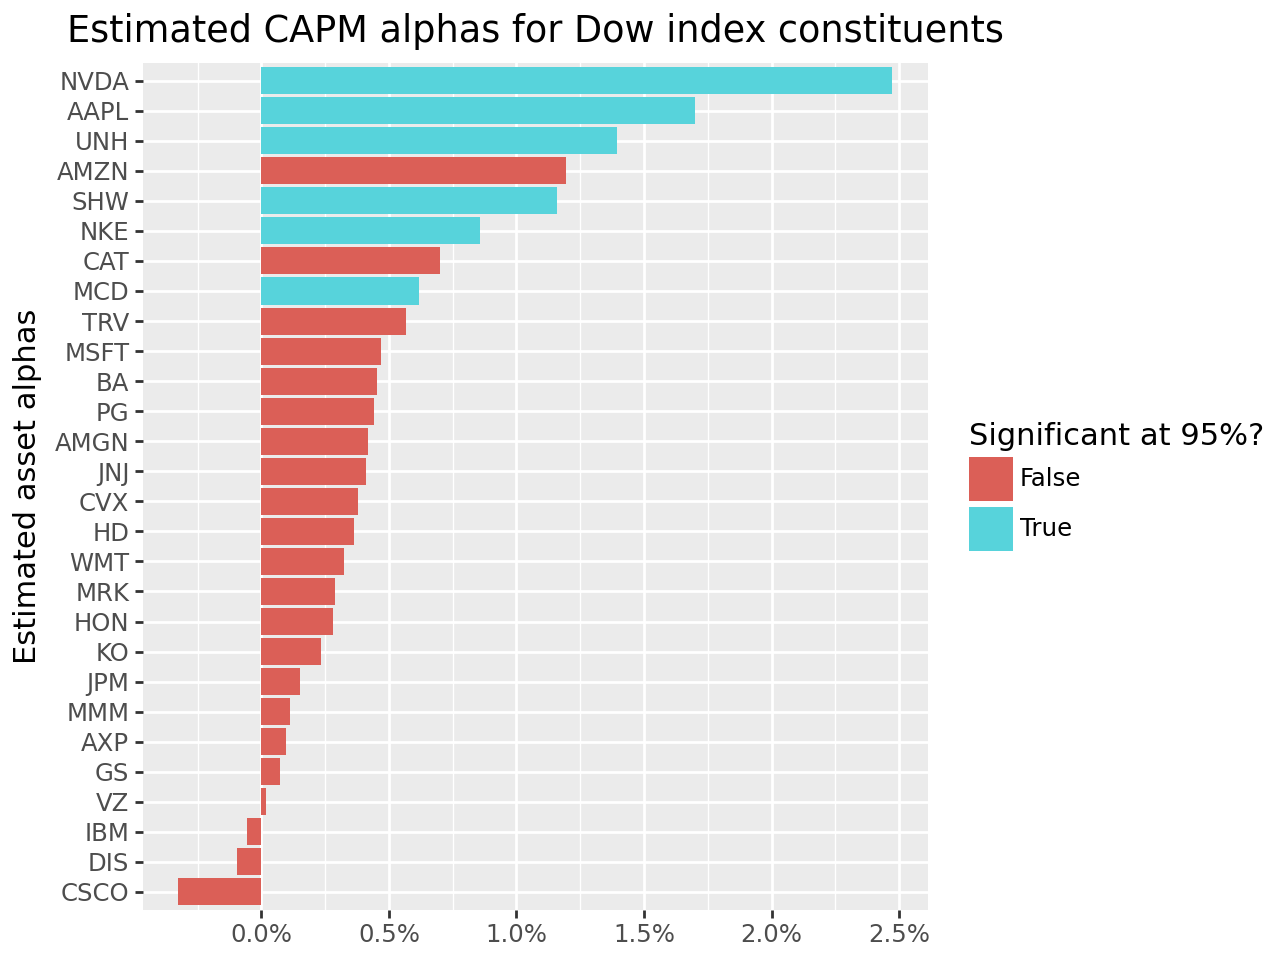

In [10]:
#| label: fig-305
#| fig-cap: "Estimates are based on returns adjusted for dividend payments and stock splits and using the Fama-French market excess returns as a measure for the market." 
#| fig-alt: "Title: Estimated CAPM alphas for Dow index constituents. The figure shows a bar chart with estimated alphas and indicates whether an estimate is statistically significant at 95%. Only Nvidia exhibits a statistically significant positive alpha."
alphas = (capm_results
  .query("coefficient=='alpha'")
  .assign(is_significant=lambda x: np.abs(x["t_statistic"]) >= 1.96)
)

alphas["symbol"] = pd.Categorical(
  alphas["symbol"],
  categories=alphas.sort_values("estimate")["symbol"],
  ordered=True
)

(
  ggplot(
    alphas,
    aes(y="estimate", x="symbol", fill="is_significant")
  )
  + geom_col()
  + scale_y_continuous(labels=percent_format())
  + coord_flip()
  + labs(
    x="Estimated asset alphas", y="", fill="Significant at 95%?",
    title="Estimated CAPM alphas for Dow index constituents"
  )
)

[1] Obviously, the market portfolio is the efficient tangency portfolio
*only* if the strict assumptions of the CAPM hold: The model describes
equilibrium in a single-period economy, markets are frictionless, with
no transaction costs or taxes, all investors can borrow and lend at the
risk-free rate, investors share the same expectations about returns and
risks, investors are rational, seeking to maximize returns for a given
level of risk.

Most notably, our analysis shows that only very few assets exhibit a
statistically significant positive alpha during our sample period. This
finding aligns with the exceptional performance of technology stocks,
particularly those involved in AI and chip manufacturing, but suggests
that most Dow components’ returns can be explained by their market
exposure alone.

## Shortcomings & Extensions

While the CAPM’s elegance and simplicity have made it a cornerstone of
modern finance, the model faces several important challenges in
practice. A fundamental challenge lies in the identification of the
market portfolio. The CAPM theory requires a truly universal market
portfolio that includes all investable assets – not just stocks, but
also real estate, private businesses, human capital, and even intangible
assets. In practice, we must rely on proxies like the S&P 500, DAX, or
TOPIX. The choice of market proxy can significantly impact our estimates
and may need to be tailored to specific contexts. For instance, a
U.S.-focused investor might use the S&P 500, while a Japanese investor
might prefer the TOPIX.

Another crucial limitation concerns the stability of beta over time. The
model assumes that an asset’s systematic risk remains constant, but this
rarely holds in practice. Companies undergo significant changes that can
affect their market sensitivity: they may alter their capital structure,
enter new markets, face new competitors, or transform their business
models. Consider how tech companies’ betas might change as they mature
from growth startups to established enterprises, or how a retailer’s
beta might shift as it expands its online presence.

Perhaps most importantly, empirical evidence suggests that systematic
risk alone cannot fully explain asset returns. Numerous studies have
documented patterns in stock returns that CAPM cannot explain. Small-cap
stocks tend to outperform large-cap stocks, and value stocks (those with
high book-to-market ratios) tend to outperform growth stocks, even after
adjusting for market risk. These “anomalies” suggest that investors may
care about multiple dimensions of risk beyond market sensitivity.

These limitations have spawned a rich literature of alternative and
extended models. The Fama-French three-factor model \[@@Fama1992\]
represents a seminal extension, adding two factors to capture the size
and value effects:

-   The SMB (Small Minus Big) factor captures the tendency of small
    stocks to outperform large stocks, as we discuss in our chapter
    [Size Sorts and P-Hacking](size-sorts-and-p-hacking.qmd).
-   The HML (High Minus Low) factor captures the tendency of value
    stocks to outperform growth stocks, as we show in [Value and
    Bivariate Sorts](value-and-bivariate-sorts.qmd).

Building on this framework, the Fama-French five-factor model
\[@FamaFrench2015\] adds two more dimensions, which we later discuss in
[Replicating Fama-French
Factors](replicating-fama-and-french-factors.qmd):

-   The RMW (Robust Minus Weak) factor captures the outperformance of
    companies with strong operating profitability
-   The CMA (Conservative Minus Aggressive) factor reflects the tendency
    of companies with conservative investment policies to outperform
    those with aggressive investment policies

The field continues to evolve with various theoretical and empirical
innovations. The Consumption CAPM links asset prices to macroeconomic
risks through aggregate consumption. The Conditional CAPM
\[@Jagannathan1996\] allows risk premiums and betas to vary with the
business cycle. The Carhart four-factor model \[@Carhart1997\] adds
momentum to the three-factor framework, while the Q-factor model and
investment CAPM \[@Hou2015\] provide alternative theoretical foundations
rooted in corporate finance.

Despite its limitations, the CAPM remains valuable as a conceptual
framework and practical tool. Its core insight – that only systematic
risk should be priced in equilibrium – continues to influence how we
think about risk and return. Understanding both its strengths and
weaknesses helps us apply it more effectively and appreciate the
contributions of newer models that build upon its foundation.

## Key Takeaways

The CAPM provides a fundamental framework for understanding asset
pricing and risk-return relationships. The key insights from this
chapter are:

-   The CAPM is an equilibrium model that assumes a frictionless economy
    where investors can freely trade without costs and borrow or lend at
    the risk-free rate
-   In equilibrium, all investors hold some combination of the market
    portfolio and the risk-free asset, with their risk preferences
    determining only the proportion of each of the two.
-   Expected returns follow a linear relationship with systematic risk:
    Assets with higher market sensitivity (beta) should earn higher
    returns to compensate investors for bearing undiversifiable risk.
-   Beta measures an asset’s sensitivity to market movements and can be
    estimated through linear regression of asset excess returns on
    market excess returns.
-   While the model has limitations, its insights about systematic
    versus idiosyncratic risk continue to influence both academic
    research and practical investment decisions.

## Exercises

1.  Download daily returns for a German stock of your choice and the S&P
    500 index for the past five years. Calculate the stock’s beta and
    interpret its meaning. How does your estimate change if you use
    daily instead of monthly returns?
2.  Compare the betas of stocks estimated using different market proxies
    (e.g., S&P 500, Russell 3000, MSCI World). How do the differences in
    market definition affect your conclusions about systematic risk?
3.  Select a mutual fund and estimate its alpha and beta relative to its
    benchmark index. Is the fund’s performance statistically significant
    after accounting for market risk? How do your conclusions change if
    you use a different benchmark?
4.  Compare betas of multinational companies using both local and global
    market indices. How do the estimates differ? What might explain
    these differences?